In [2]:
#r "nuget:ScottPlot, 5.0.*"

Installed Packages ScottPlot, 5.0.55

Loading extensions from `/Users/artemiy/.nuget/packages/skiasharp/2.88.9/interactive-extensions/dotnet/SkiaSharp.DotNet.Interactive.dll`

In [1]:
#r "task14.dll"

In [3]:
using Microsoft.DotNet.Interactive.Formatting;
Formatter.Register(typeof(ScottPlot.Plot), (p, w) => 
    w.Write(((ScottPlot.Plot)p).GetPngHtml(400, 300)), HtmlFormatter.MimeType);

1E-06: 9.519474327770192E-15
1E-05: -7.124882010333539E-15
0.0001: -1.7828959337530537E-15
0.001: -1.4415768925801764E-14
0.01: -5.0948828489438824E-15
0.1: -1.6604773112049998E-14



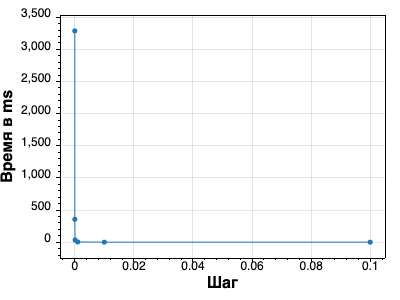

In [4]:
using System.Diagnostics;
using task14;

var steps = new[] { 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1 };
var results = steps.Select(step =>
{
    var sw = Stopwatch.StartNew();
    var res =  DefiniteIntegral.Solve(-100, 100, Math.Sin, step);
    Console.WriteLine($"{step}: {res}");
    sw.Stop();

    return sw.ElapsedMilliseconds;
}).ToArray();

var plt = new ScottPlot.Plot();
plt.Add.Scatter(steps, results);
plt.XLabel("Шаг");
plt.YLabel("Время в ms");
plt.SavePng("steps.png", 600, 400);
plt


Время без потоков (среднее за 150 итераций): 34.55266666666661
Время для 1 потока (среднее за 150 итераций): 40.826
Время для 2 потока (среднее за 150 итераций): 21.19333333333333
Время для 3 потока (среднее за 150 итераций): 17.17733333333333
Время для 4 потока (среднее за 150 итераций): 14.716000000000003
Время для 5 потока (среднее за 150 итераций): 22.21466666666666
Время для 6 потока (среднее за 150 итераций): 24.15333333333332
Время для 7 потока (среднее за 150 итераций): 21.050000000000008
Время для 8 потока (среднее за 150 итераций): 22.737999999999985
Время для 9 потока (среднее за 150 итераций): 23.79266666666667
Время для 10 потока (среднее за 150 итераций): 20.726000000000013
Время для 11 потока (среднее за 150 итераций): 22.83599999999999



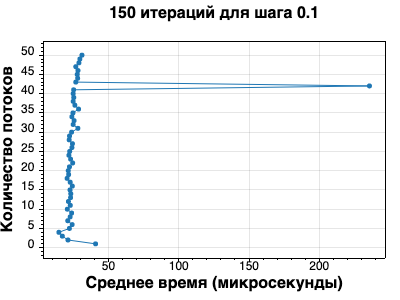

In [5]:
using System.Diagnostics;

Func<double, double> func = Math.Sin;

var step = 1e-1;
int repeats = 150;
var threadCounts = Enumerable.Range(1, 50).ToArray();

var avgTimes = threadCounts.Select(threadCount =>
{
    var total = 0D;

    for (int i = 0; i < repeats; i++)
    {
        var sw = Stopwatch.StartNew();
        var res = DefiniteIntegral.Solve(-100, 100, func, step, threadCount);
        sw.Stop();
        total += sw.Elapsed.TotalMicroseconds;
    }

    return (double)total / repeats;
}).ToArray();

var time = 0D;

for (int i = 0; i < repeats; i++)
{
    var sw = Stopwatch.StartNew();
    var withoutThreads = DefiniteIntegral.Solve(-100, 100, func, step);
    sw.Stop();
    time += sw.Elapsed.TotalMicroseconds;
}

Console.WriteLine($"Время без потоков (среднее за 150 итераций): {time / repeats}");

for (int i = 0; i < 11; i++)
{
    Console.WriteLine($"Время для {i + 1} потока (среднее за 150 итераций): {avgTimes[i]}");
}

var plt = new ScottPlot.Plot();
plt.Add.Scatter(avgTimes, threadCounts);
plt.YLabel("Количество потоков");
plt.XLabel("Среднее время (микросекунды)");
plt.Title($"{repeats} итераций для шага {step}");
plt.SavePng("threads.png", 600, 400);
plt